# Sentiment Analysis using NLP Pipeline & ML Models

## Objective
This project aims to build an end-to-end Sentiment Analysis system using Natural Language Processing (NLP) and Machine Learning models.

Pipeline:
Raw Text → Preprocessing → Feature Engineering → Model Training → Evaluation → Comparison

## Models Used
- Logistic Regression
- Naive Bayes
- Decision Tree

## Feature Techniques
- Bag of Words (BoW)
- TF-IDF

In [27]:
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')IMDB Dataset.csv

SyntaxError: invalid syntax (667671123.py, line 25)

In [28]:
# Load dataset 
df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [29]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)

print("\nMissing Values:\n", df.isnull().sum())

print("\nClass Distribution:\n", df['sentiment'].value_counts())

Shape: (50000, 2)

Columns: Index(['review', 'sentiment'], dtype='object')

Missing Values:
 review       0
sentiment    0
dtype: int64

Class Distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [30]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Cleaned Shape:", df.shape)

Cleaned Shape: (49582, 2)


## NLP Preprocessing Steps
- Lowercasing
- Remove punctuation
- Remove URLs
- Remove numbers
- Remove stopwords
- Tokenization
- Lemmatization

In [31]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    return " ".join(tokens)

In [32]:
df['cleaned_text'] = df['review'].apply(preprocess_text)

df[['review', 'cleaned_text']].head()

,review,cleaned_text
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode you...
1,A wonderful little production. <br /><br />The...,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,basically there family little boy jake think t...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter matteis love time money visually stunni...


In [33]:
# For binary dataset
label_map = {'negative': 0, 'positive': 1}
df['sentiment_encoded'] = df['sentiment'].map(label_map)

df.head()

,review,sentiment,cleaned_text,sentiment_encoded
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode you...,1
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...,1
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...,1
3,Basically there's a family where a little boy ...,negative,basically there family little boy jake think t...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...,1


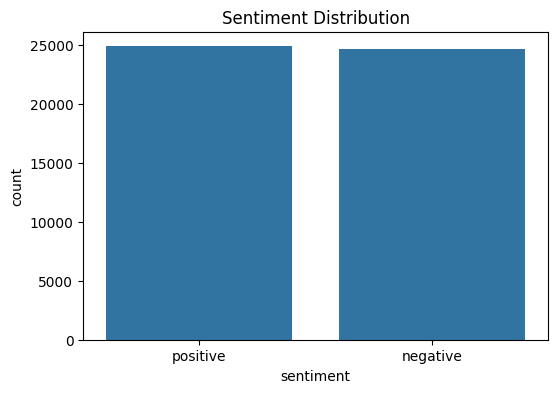

In [34]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [35]:
X = df['cleaned_text']
y = df['sentiment_encoded']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
bow = CountVectorizer(max_features=5000)

X_train_bow = bow.fit_transform(X_train)
X_test_bow = bow.transform(X_test)

In [38]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [39]:
results = []

def evaluate(model, Xtr, Xte, ytr, yte, model_name, vec_name):
    model.fit(Xtr, ytr)
    pred = model.predict(Xte)
    
    acc = accuracy_score(yte, pred)
    prec = precision_score(yte, pred)
    rec = recall_score(yte, pred)
    f1 = f1_score(yte, pred)
    
    results.append([vec_name, model_name, acc, prec, rec, f1])
    
    print("\n", "="*40)
    print(model_name, "|", vec_name)
    print("="*40)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    
    print("\nReport:\n", classification_report(yte, pred))
    
    cm = confusion_matrix(yte, pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(model_name)
    plt.show()


Logistic Regression | BoW
Accuracy: 0.8662902087324795
Precision: 0.8604421634425582
Recall: 0.8756528726396143
F1: 0.8679808841099164

Report:
               precision    recall  f1-score   support

           0       0.87      0.86      0.86      4939
           1       0.86      0.88      0.87      4978

    accuracy                           0.87      9917
   macro avg       0.87      0.87      0.87      9917
weighted avg       0.87      0.87      0.87      9917



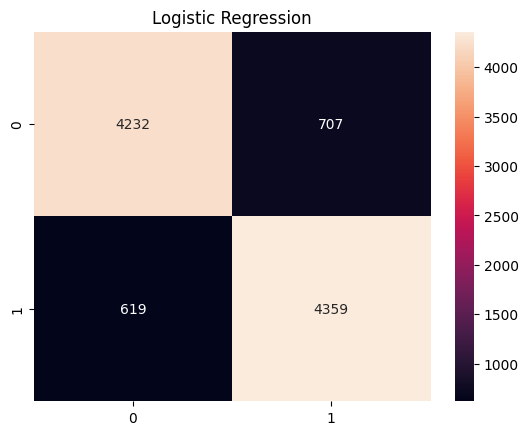


Naive Bayes | BoW
Accuracy: 0.8424926893213673
Precision: 0.8474369406021155
Recall: 0.8368822820409804
F1: 0.8421265413381848

Report:
               precision    recall  f1-score   support

           0       0.84      0.85      0.84      4939
           1       0.85      0.84      0.84      4978

    accuracy                           0.84      9917
   macro avg       0.84      0.84      0.84      9917
weighted avg       0.84      0.84      0.84      9917



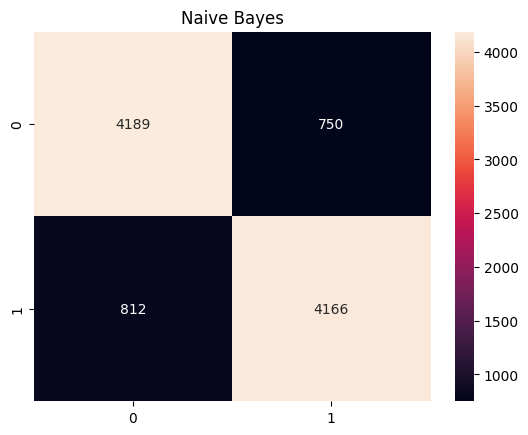


Decision Tree | BoW
Accuracy: 0.7033377029343552
Precision: 0.7034372501998402
Recall: 0.707111289674568
F1: 0.7052694850731316

Report:
               precision    recall  f1-score   support

           0       0.70      0.70      0.70      4939
           1       0.70      0.71      0.71      4978

    accuracy                           0.70      9917
   macro avg       0.70      0.70      0.70      9917
weighted avg       0.70      0.70      0.70      9917



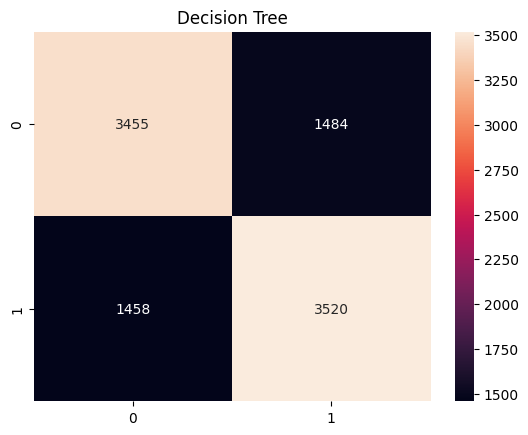

In [40]:
evaluate(LogisticRegression(), X_train_bow, X_test_bow, y_train, y_test, "Logistic Regression", "BoW")
evaluate(MultinomialNB(), X_train_bow, X_test_bow, y_train, y_test, "Naive Bayes", "BoW")
evaluate(DecisionTreeClassifier(), X_train_bow, X_test_bow, y_train, y_test, "Decision Tree", "BoW")


Logistic Regression | TF-IDF
Accuracy: 0.8828274679842695
Precision: 0.8725107379929715
Recall: 0.8977501004419446
F1: 0.884950495049505

Report:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88      4939
           1       0.87      0.90      0.88      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



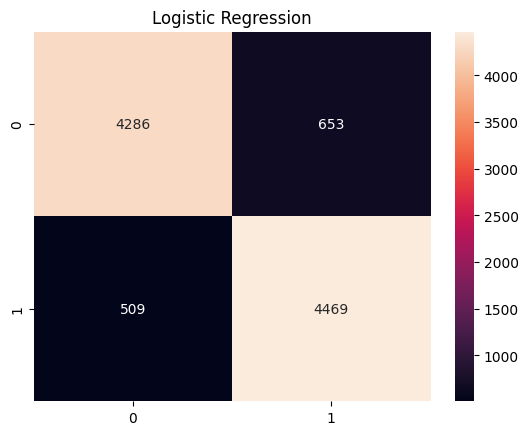


Naive Bayes | TF-IDF
Accuracy: 0.8496521125340325
Precision: 0.846001190712443
Recall: 0.8563680192848534
F1: 0.8511530398322851

Report:
               precision    recall  f1-score   support

           0       0.85      0.84      0.85      4939
           1       0.85      0.86      0.85      4978

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



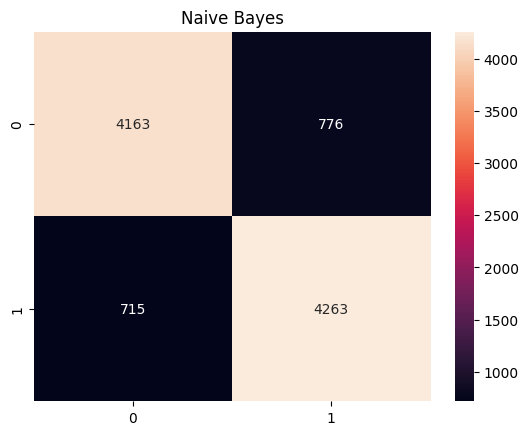


Decision Tree | TF-IDF
Accuracy: 0.7033377029343552
Precision: 0.705407586763519
Recall: 0.7022900763358778
F1: 0.7038453795047313

Report:
               precision    recall  f1-score   support

           0       0.70      0.70      0.70      4939
           1       0.71      0.70      0.70      4978

    accuracy                           0.70      9917
   macro avg       0.70      0.70      0.70      9917
weighted avg       0.70      0.70      0.70      9917



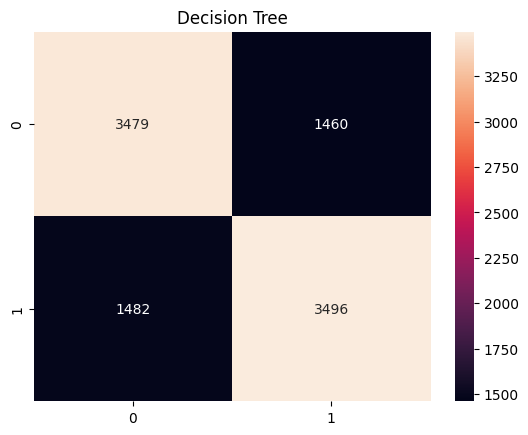

In [41]:
evaluate(LogisticRegression(), X_train_tfidf, X_test_tfidf, y_train, y_test, "Logistic Regression", "TF-IDF")
evaluate(MultinomialNB(), X_train_tfidf, X_test_tfidf, y_train, y_test, "Naive Bayes", "TF-IDF")
evaluate(DecisionTreeClassifier(), X_train_tfidf, X_test_tfidf, y_train, y_test, "Decision Tree", "TF-IDF")

In [42]:
results_df = pd.DataFrame(results, columns=["Vectorizer", "Model", "Accuracy", "Precision", "Recall", "F1"])

results_df

,Vectorizer,Model,Accuracy,Precision,Recall,F1
0,BoW,Logistic Regression,0.866290,0.860442,0.875653,0.867981
1,BoW,Naive Bayes,0.842493,0.847437,0.836882,0.842127
2,BoW,Decision Tree,0.703338,0.703437,0.707111,0.705269
3,TF-IDF,Logistic Regression,0.882827,0.872511,0.897750,0.884950
4,TF-IDF,Naive Bayes,0.849652,0.846001,0.856368,0.851153
5,TF-IDF,Decision Tree,0.703338,0.705408,0.702290,0.703845


In [43]:
results_df.sort_values(by="F1", ascending=False)

,Vectorizer,Model,Accuracy,Precision,Recall,F1
3,TF-IDF,Logistic Regression,0.882827,0.872511,0.897750,0.884950
0,BoW,Logistic Regression,0.866290,0.860442,0.875653,0.867981
4,TF-IDF,Naive Bayes,0.849652,0.846001,0.856368,0.851153
1,BoW,Naive Bayes,0.842493,0.847437,0.836882,0.842127
2,BoW,Decision Tree,0.703338,0.703437,0.707111,0.705269
5,TF-IDF,Decision Tree,0.703338,0.705408,0.702290,0.703845


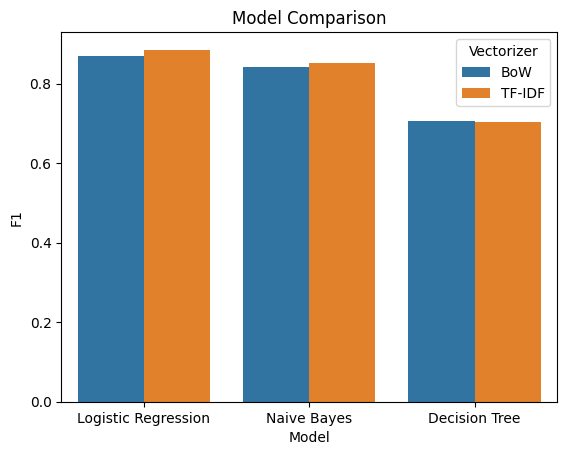

In [44]:
sns.barplot(x="Model", y="F1", hue="Vectorizer", data=results_df)
plt.title("Model Comparison")
plt.show()

In [45]:
final_vec = TfidfVectorizer(max_features=5000)
X_train_final = final_vec.fit_transform(X_train)

final_model = LogisticRegression()
final_model.fit(X_train_final, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [46]:
def predict(text):
    clean = preprocess_text(text)
    vec = final_vec.transform([clean])
    pred = final_model.predict(vec)[0]
    
    return "Positive" if pred == 1 else "Negative"

In [47]:
texts = [
    "I love this product",
    "Worst experience ever",
    "It was okay not great"
]

for t in texts:
    print(t, "->", predict(t))

I love this product -> Positive
Worst experience ever -> Negative
It was okay not great -> Positive


# Insights

- TF-IDF performed better than Bag of Words
- Logistic Regression gave best results
- Naive Bayes was fastest but less accurate
- Decision Tree overfitted in some cases

# Best Model
TF-IDF + Logistic Regression

# Conclusion
The NLP pipeline successfully transformed raw text into features and enabled accurate sentiment classification.